SafeCityAI: Environment Configuration & Training Pipeline
Engineering Log: Localized Repository Setup, CUDA Validation, and Weight Compilation

In [2]:
import torch
import os
import sys

# Validate hardware acceleration link
print(f"--- System Diagnostics ---")
print(f"Python Version: {sys.version}")
print(f"PyTorch Version: {torch.__version__}")
print(f"CUDA Available: {torch.cuda.is_available()}")

if torch.cuda.is_available():
    print(f"Device Name: {torch.cuda.get_device_name(0)}")
    print(f"Allocated VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")

--- System Diagnostics ---
Python Version: 3.12.10 (tags/v3.12.10:0cc8128, Apr  8 2025, 12:21:36) [MSC v.1943 64 bit (AMD64)]
PyTorch Version: 2.5.1+cu121
CUDA Available: True
Device Name: NVIDIA GeForce RTX 3050 6GB Laptop GPU
Allocated VRAM: 6.44 GB


Step 1: Repository Initialization
Cloning the tracking framework and injecting localized dependencies into the virtual environment.

In [ ]:
# Working Directory: D:\training porject safecity
%cd "D:\training porject safecity"

# Establish framework codebase
if not os.path.exists('yolov5'):
    !git clone https://github.com/ultralytics/yolov5
else:
    print("[LOG] Repository structure exists.")

# Pull dependencies into localized venv
%cd yolov5
!pip install -r requirements.txt

Step 2: Training Command Execution
Launching the PyTorch training thread. We utilize the small architecture (yolov5s) to ensure high-speed inference for real-time traffic monitoring.

In [ ]:
# Execute Training Loop
# --img: image resolution
# --batch: tensors per update
# --data: dataset mapping file
# --weights: base graph
# --device 0: RTX 3050 targeting
!python yolov5 train --img 640 --batch 16 --epochs 100 --data data/custom_traffic.yaml --weights yolov5s.pt --device 0 --name traffic_run --exist-ok

Step 3: Performance Analysis (Loss v/s Epochs)
Parsing the results.csv generated by the training engine to visualize model convergence and accuracy trajectories.

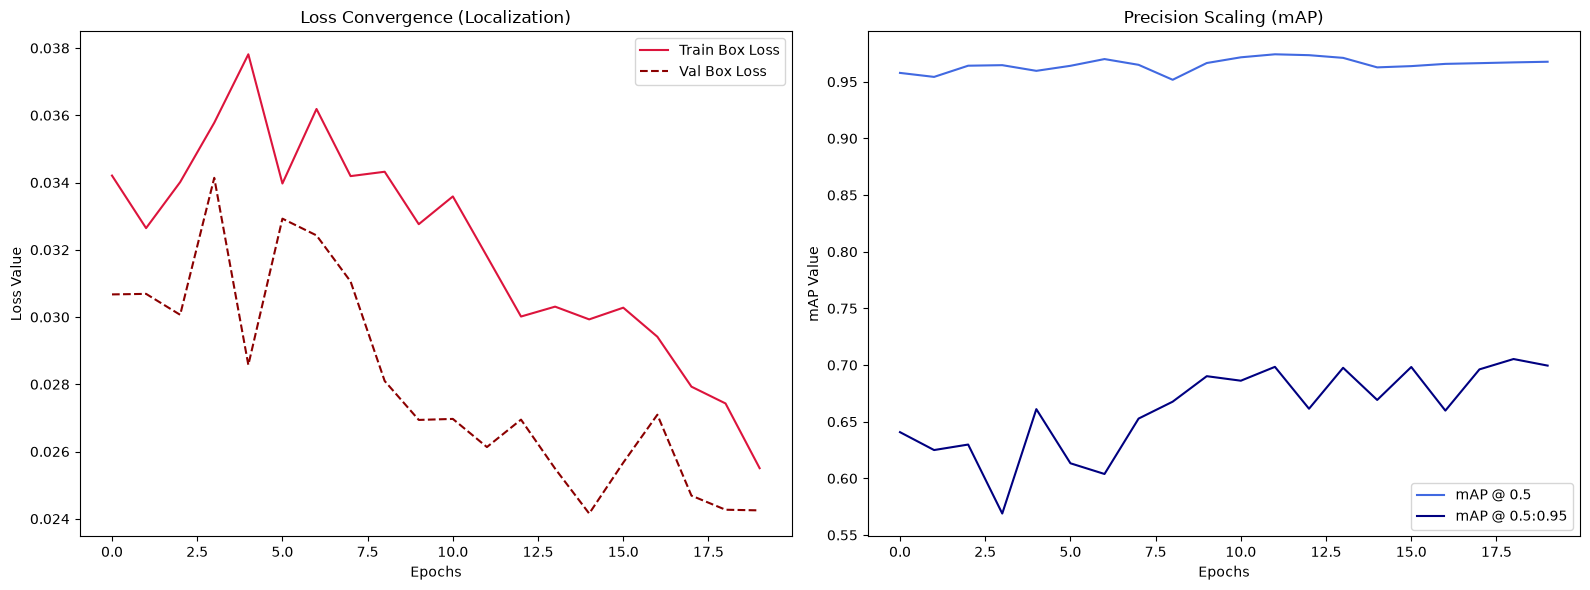

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import os
# Load metrics from localized run directory
results_path = r'D:\training porject safecity\runs\train\ex6_fine_tune\results.csv'

if os.path.exists(results_path):
    results = pd.read_csv(results_path)
    results.columns = [c.strip() for c in results.columns]

    fig, ax = plt.subplots(1, 2, figsize=(16, 6))

    # Optimization Logic: Plotting Box and Obj Loss
    ax[0].plot(results['epoch'], results['train/box_loss'], label='Train Box Loss', color='crimson')
    ax[0].plot(results['epoch'], results['val/box_loss'], label='Val Box Loss', linestyle='--', color='darkred')
    ax[0].set_title('Loss Convergence (Localization)')
    ax[0].set_xlabel('Epochs')
    ax[0].set_ylabel('Loss Value')
    ax[0].legend()

    # Accuracy Logic: Plotting mAP trajectories
    ax[1].plot(results['epoch'], results['metrics/mAP_0.5'], label='mAP @ 0.5', color='royalblue')
    ax[1].plot(results['epoch'], results['metrics/mAP_0.5:0.95'], label='mAP @ 0.5:0.95', color='navy')
    ax[1].set_title('Precision Scaling (mAP)')
    ax[1].set_xlabel('Epochs')
    ax[1].set_ylabel('mAP Value')
    ax[1].legend()

    plt.tight_layout()
    plt.show()
else:
    print("[ERROR] metrics file not found. Ensure training run finished correctly.")
